In [47]:
from __future__ import annotations

import os
import re
import glob
from dataclasses import dataclass
from datetime import datetime
from typing import List, Tuple
import ast
import numpy as np
FNAME_RE = re.compile(
    r"^New_initialized_calibration_freq_files_(\d{8})_(\d{4})(?:\.[^.]+)?$"
)

@dataclass
class ParsedRecord:
    mtime: datetime
    first_value: float
    path: str

def parse_filename_timestamp(filename: str) -> datetime | None:
    m = FNAME_RE.match(filename)
    if not m:
        return None
    yyyymmdd, hhmm = m.group(1), m.group(2)
    return datetime.strptime(yyyymmdd + hhmm, "%Y%m%d%H%M")

def parse_first_line(line: str) -> Tuple[float, str]:
    """
    Parse lines like:
      546.10164, 97.977, [0, 2, 0]
      546.10164, 97.977, 0

    IMPORTANT: only split the first two commas so the list stays intact.
    """
    line = line.strip()
    a, b, c = [p.strip() for p in line.split(",", 2)]  # maxsplit=2
    first_num = float(a)
    last_field = c  # either "0" or "[0, 2, 0]"
    return first_num, last_field

def load_records_after(directory: str, cutoff: datetime) -> Tuple[List[ParsedRecord], List[ParsedRecord]]:
    pattern = os.path.join(directory, "New_initialized_calibration_freq_files_*_*")
    paths = glob.glob(pattern)

    freq_scan: List[ParsedRecord] = []
    ramsey: List[ParsedRecord] = []

    for path in paths:
        base = os.path.basename(path)

        file_dt = parse_filename_timestamp(base)
        if file_dt is None or file_dt <= cutoff:
            continue

        mtime = datetime.fromtimestamp(os.path.getmtime(path))

        first_line = ""
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            for line in f:
                if line.strip():
                    first_line = line
                    break
        if not first_line:
            continue

        try:
            first_num, last_field = parse_first_line(first_line)
        except Exception:
            continue

        if last_field == "0" or last_field == "0.0":
            freq_scan.append(ParsedRecord(mtime=mtime, first_value=first_num, path=path))
        elif last_field.startswith("[") and last_field.endswith("]"):
            try:
                val = ast.literal_eval(last_field)
                if isinstance(val, list):
                    ramsey.append(ParsedRecord(mtime=mtime, first_value=first_num, path=path))
            except Exception:
                continue
        else:
            continue

    freq_scan.sort(key=lambda r: r.mtime)
    ramsey.sort(key=lambda r: r.mtime)
    return freq_scan, ramsey


directory = r"Z:\Lab Data\D52_Calibration_Ba137\New_initialized_calibration_freq_files"
cutoff = datetime(2026, 1, 28, 15, 35)

freq_scan_records, ramsey_records = load_records_after(directory, cutoff)

freq_scan_mtimes = [r.mtime for r in freq_scan_records]
freq_scan_freqs  = [r.first_value for r in freq_scan_records]

ramsey_mtimes = [r.mtime for r in ramsey_records]
ramsey_freqs  = [r.first_value for r in ramsey_records]

print("freq_scan:", len(freq_scan_freqs))
print("ramsey:", len(ramsey_freqs))


freq_scan: 0
ramsey: 151


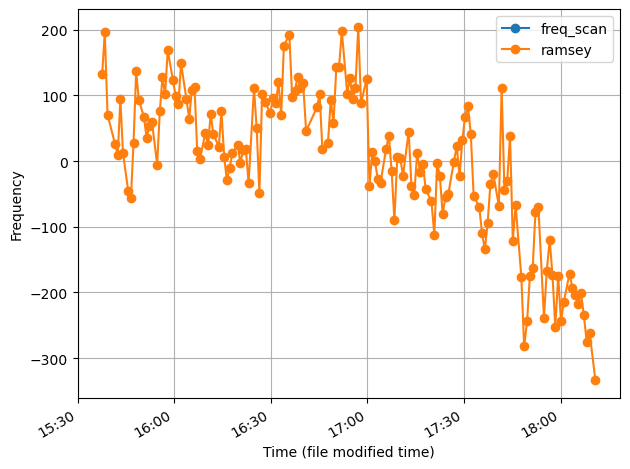

In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots()

ax.plot(freq_scan_mtimes, freq_scan_freqs, "-o", label="freq_scan")
ax.plot(ramsey_mtimes, (np.array(ramsey_freqs) - np.mean(ramsey_freqs))*1e6,"-o", label="ramsey")

ax.set_xlabel("Time (file modified time)")
ax.set_ylabel("Frequency")
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.grid()
plt.tight_layout()
plt.show()
